#Toyota Used Cars Exploratory Data Analysis (EDA)

## Objective

The objective of this project is to explore the Toyota Used Cars dataset, clean the data, analyze different features, visualize patterns, and generate business insights using Python, Pandas, Matplotlib, and Seaborn.


### Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
cars = pd.read_csv("Toyota.csv", na_values=["??","????"])

In [3]:
cars.head()

,Unnamed: 0,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,0,13500,23.0,46986.0,Diesel,90.0,1.0,0,2000,three,1165
1,1,13750,23.0,72937.0,Diesel,90.0,1.0,0,2000,3,1165
2,2,13950,24.0,41711.0,Diesel,90.0,NaN,0,2000,3,1165
3,3,14950,26.0,48000.0,Diesel,90.0,0.0,0,2000,3,1165
4,4,13750,30.0,38500.0,Diesel,90.0,0.0,0,2000,3,1170


In [4]:
cars.tail()

,Unnamed: 0,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
1431,1431,7500,NaN,20544.0,Petrol,86.0,1.0,0,1300,3,1025
1432,1432,10845,72.0,NaN,Petrol,86.0,0.0,0,1300,3,1015
1433,1433,8500,NaN,17016.0,Petrol,86.0,0.0,0,1300,3,1015
1434,1434,7250,70.0,NaN,NaN,86.0,1.0,0,1300,3,1015
1435,1435,6950,76.0,1.0,Petrol,110.0,0.0,0,1600,5,1114


In [5]:
cars.sample(5)

,Unnamed: 0,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
1338,1338,7499,80.0,63500.0,Petrol,110.0,1.0,0,1600,3,1050
1009,1009,8900,59.0,36954.0,Petrol,110.0,1.0,0,1600,3,1050
143,143,18500,16.0,20629.0,Petrol,110.0,1.0,0,1600,4,1090
1127,1127,8700,75.0,109540.0,Petrol,110.0,0.0,0,1600,5,1085
108,108,17950,20.0,7187.0,Petrol,110.0,1.0,0,1600,3,1105


In [6]:
cars.shape

(1436, 11)

In [7]:
cars.columns

Index(['Unnamed: 0', 'Price', 'Age', 'KM', 'FuelType', 'HP', 'MetColor',
       'Automatic', 'CC', 'Doors', 'Weight'],
      dtype='object')

In [8]:
cars.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  1436 non-null   int64  
 1   Price       1436 non-null   int64  
 2   Age         1336 non-null   float64
 3   KM          1421 non-null   float64
 4   FuelType    1336 non-null   object 
 5   HP          1430 non-null   float64
 6   MetColor    1286 non-null   float64
 7   Automatic   1436 non-null   int64  
 8   CC          1436 non-null   int64  
 9   Doors       1436 non-null   object 
 10  Weight      1436 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 123.5+ KB


In [9]:
cars.drop(columns=["Unnamed: 0"], inplace=True)

In [10]:
cars.head()

,Price,Age,KM,FuelType,HP,MetColor,Automatic,CC,Doors,Weight
0,13500,23.0,46986.0,Diesel,90.0,1.0,0,2000,three,1165
1,13750,23.0,72937.0,Diesel,90.0,1.0,0,2000,3,1165
2,13950,24.0,41711.0,Diesel,90.0,NaN,0,2000,3,1165
3,14950,26.0,48000.0,Diesel,90.0,0.0,0,2000,3,1165
4,13750,30.0,38500.0,Diesel,90.0,0.0,0,2000,3,1170


## Observations

- Dataset contains 1436 records.
- There are 11 columns.
- Both numerical and categorical features are present.
- Some columns contain missing values.

In [11]:
cars.isnull().sum()

,0
Price,0
Age,100
KM,15
FuelType,100
HP,6
MetColor,150
Automatic,0
CC,0
Doors,0
Weight,0


#Handling the missing values

In [12]:
cars["KM"].fillna(cars["KM"].median(), inplace=True)

/tmp/ipykernel_4360/37583120.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  cars["KM"].fillna(cars["KM"].median(), inplace=True)


In [13]:
cars["Age"] = cars["Age"].fillna(cars["Age"].median())

In [14]:
cars["HP"] = cars["HP"].fillna(cars["HP"].median())

In [15]:
cars["FuelType"] = cars["FuelType"].fillna(cars["FuelType"].mode()[0])

In [16]:
cars["MetColor"] = cars["MetColor"].fillna(cars["MetColor"].mode()[0])

In [17]:
cars.isnull().sum()

,0
Price,0
Age,0
KM,0
FuelType,0
HP,0
MetColor,0
Automatic,0
CC,0
Doors,0
Weight,0


### Missing Value Treatment

Age- Filled using Median because the distribution is skewed.

KM - Filled using Median because mileage may contain outliers.

FuelType - Filled using Mode because it is a categorical feature.

HP - Filled using Median.

MetColor -Filled using Mode.

#Analysis

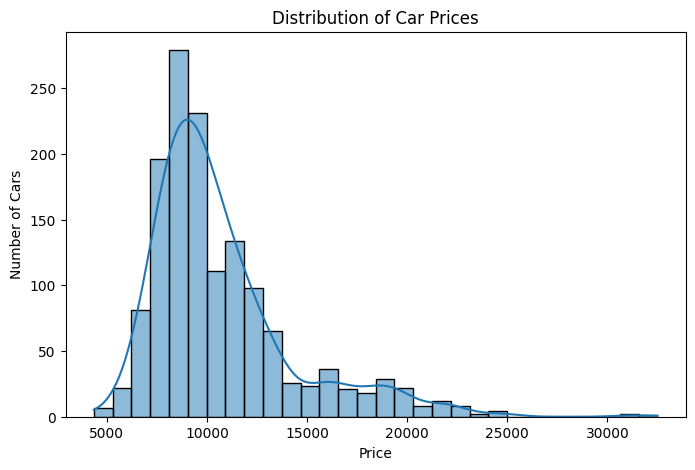

In [18]:
plt.figure(figsize=(8,5))

sns.histplot(cars["Price"], bins=30, kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")

plt.show()

### Observation

- Most cars are priced between ₹8,000 and ₹12,000.
- The distribution is positively skewed.
- A few expensive cars create a long right tail.
- The dealership mainly sells affordable used cars.

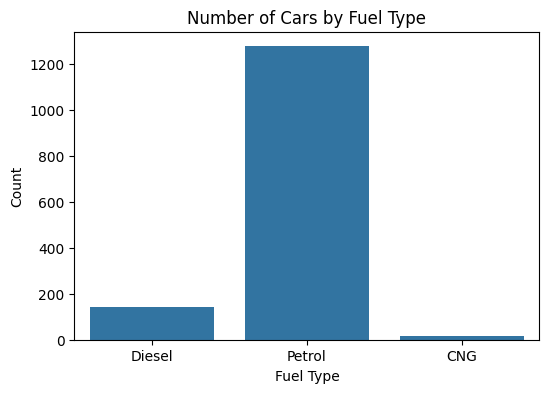

In [19]:
plt.figure(figsize=(6,4))

sns.countplot(x="FuelType", data=cars)

plt.title("Number of Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Count")

plt.show()

###Observation
The fuel type distribution shows that Petrol cars account for the majority of vehicles in the dataset. This suggests that Petrol vehicles are the primary segment represented in the inventory, while Diesel and CNG vehicles are less common.

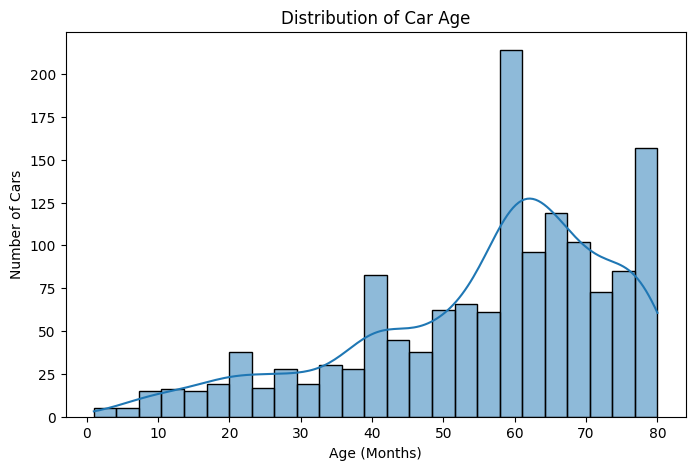

In [20]:
plt.figure(figsize=(8,5))

sns.histplot(cars["Age"], bins=25, kde=True)

plt.title("Distribution of Car Age")
plt.xlabel("Age (Months)")
plt.ylabel("Number of Cars")

plt.show()

###Observation
- The age distribution is left-skewed.
- Most cars are between 55 and 80 months old.
- Only a small number of cars are relatively new, making them potential outliers.

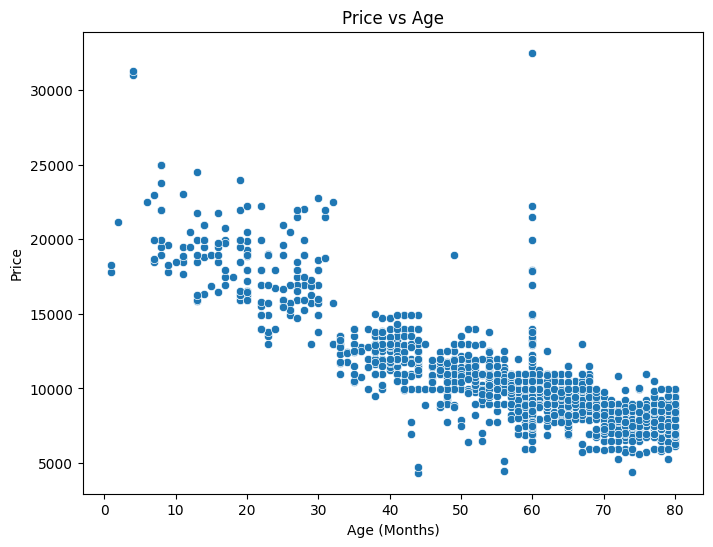

In [21]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Age",
    y="Price",
    data=cars
)

plt.title("Price vs Age")
plt.xlabel("Age (Months)")
plt.ylabel("Price")

plt.show()

In [22]:
cars[["Age", "Price"]].corr()

,Age,Price
Age,1.000000,-0.844735
Price,-0.844735,1.000000


###Observation
- There is a negative relationship between Age and Price.
- As the age of the car increases, its selling price generally decreases.
- Newer cars tend to have higher prices, while older cars are usually cheaper.

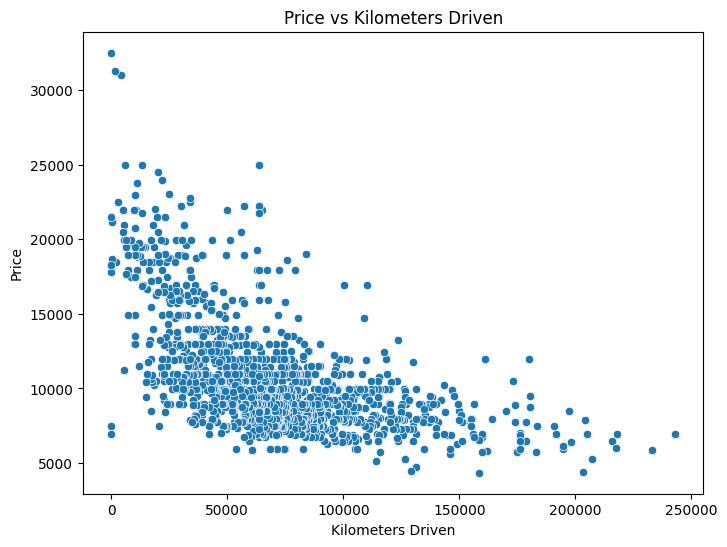

In [23]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="KM",
    y="Price",
    data=cars
)

plt.title("Price vs Kilometers Driven")
plt.xlabel("Kilometers Driven")
plt.ylabel("Price")

plt.show()

###Observation
The analysis shows a negative relationship between kilometers driven and selling price. Cars with lower mileage generally have higher resale values, while high-mileage cars tend to be cheaper. This suggests that mileage is an important factor affecting the resale value of used cars.

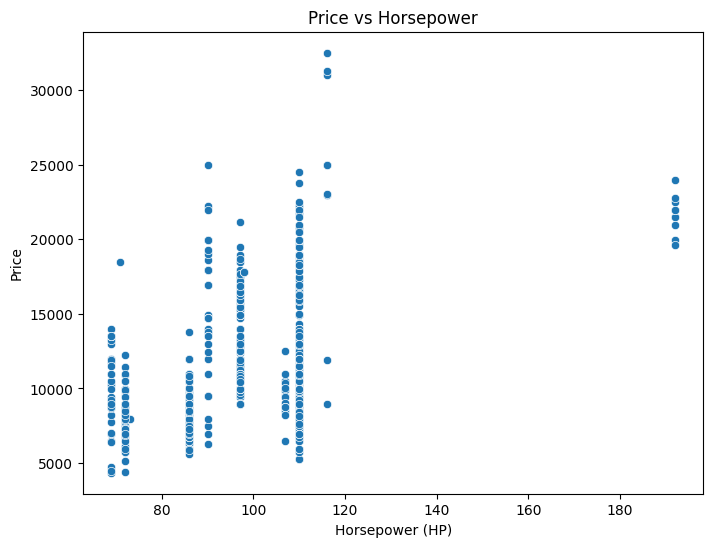

In [24]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="HP",
    y="Price",
    data=cars
)

plt.title("Price vs Horsepower")
plt.xlabel("Horsepower (HP)")
plt.ylabel("Price")

plt.show()

###Observation
There is a positive relationship between HP and Price.
Cars with higher horsepower generally have higher prices.
The relationship is not very strong because cars with the same HP can have different prices.
There are a few high-priced outliers around 115 HP.

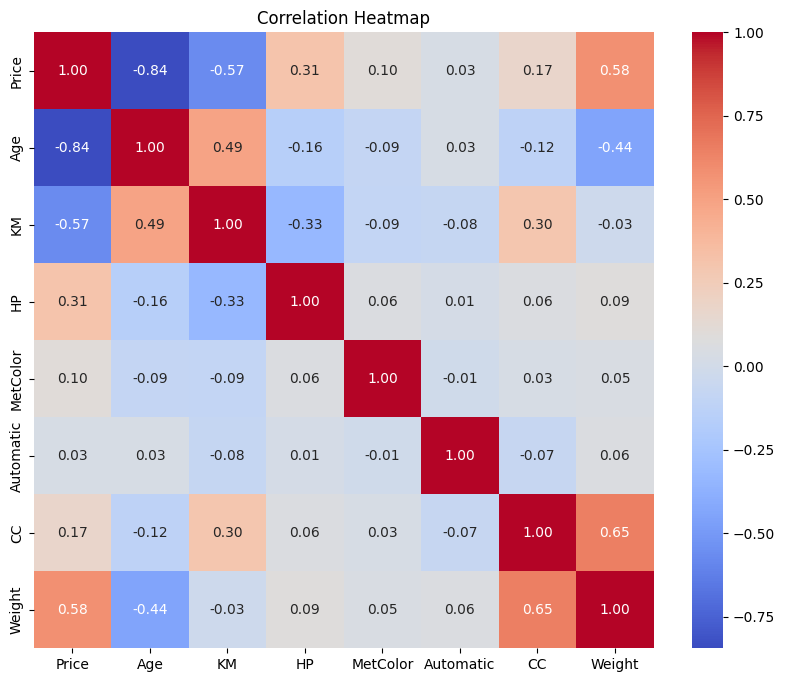

In [25]:
plt.figure(figsize=(10,8))

numeric = cars.select_dtypes(include=["number"])

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

### Observation

- Price has a strong negative correlation with Age (-0.84), indicating that older cars generally have lower selling prices.
- Price has a moderate negative correlation with Kilometers Driven (-0.57), showing that cars with higher mileage tend to be cheaper.
- Price has a moderate positive correlation with Weight (0.58), suggesting that heavier cars are generally more expensive.
- Price has a weak positive correlation with Horsepower (0.31), indicating that cars with higher horsepower tend to have slightly higher prices.
- Engine Capacity (CC) and Weight have a strong positive correlation (0.65), meaning cars with larger engines are generally heavier.
- Automatic transmission and MetColor show very weak correlations with Price, indicating they have little influence on the selling price in this dataset.

##Top Findings

Age is the strongest factor affecting Price (Correlation = -0.84).


Higher mileage is associated with lower resale prices (Correlation = -0.57).                                                       
Heavier cars tend to have higher prices (Correlation = 0.58).




# Conclusion

This project explored the Toyota Used Cars dataset using Exploratory Data Analysis.

The data was cleaned by handling missing values, followed by visualization and statistical analysis.

The study revealed that Age and Kilometers Driven have the strongest negative impact on resale price, while Horsepower and Weight show positive relationships with price.

These insights can help dealerships understand pricing patterns and make better inventory and pricing decisions.